# Mining Frequent Itemsets

### How to find frequent itemsets?

- Scan every transaction in database
- Enumerate the possible subsets
- Check whether their frequency is above the minimal support
- First find frequenct itemsets, then calculate the confidence of associations 

### A simple way of doing It

To get frequency, we just need to *count*.
- And counting is easy, right?

Except when there are too many possible candidates!
- 1000 items: 1M possible 2-itemsets; 1B possible 3-itemsets 
- Intractable even for patterns that appear

### Scale up frequent pattern mining

Intuition: the *downward closure property*

- Any subset of a frequent itemset must be frequent
- If {:beer:, :baby_bottle:, :lemon:} is frequent, so is {:beer:, :baby_bottle:}
- i.e., every transaction having {:beer:, baby_bottle:, :lemon:} also contains {:beer:, :baby_bottle:}

What does this imply?

### Apriori: candidates generation & test

- **Apriori pruning principle**: If any itemset is infrequent, none of its supersets need to be considered.

### How it works

- Initially, scan database once to get grequent 1-itemset (single items)
- Generate size (k+1) candidate itemsets from length k frequent itemsets
- Test (count) the candidates against database
- Terminate when no frequent or candidate set can be generated

### The Apriori algorithm - an example

### Example: shopping baskets

| TID | Items Bought |
|-----|-----|
| 1 | :beer:, :baby_bottle:, :watermelon: |
| 2 | :beer:, :lollipop:, :baby_bottle:, :lemon: |
| 3 | :baby_bottle:, :beer:, :lemon: |
| 4 | :baby_bottle:, :lollipop: |
| 5 | :baby_bottle:, :lollipop: |
| 6 | :wine_glass:, :cookie:, :beer:, :bread:, :lemon: |

Minimal Support = 2

first scan of DB -> 

1-itemsets 

| TID | Count |
|-----|-----|
|{:beer:}| 4 |
|{:baby_bottle:}| 4 |
|{:watermelon:}| 1 |
|{:lollipop:}| 2 |
|{:lemon:}| 2 |
|{:wine_glass:}| 1 |

-> Frequent 1-itemsets 

| TID | Count |
|---|---|
|{:beer:}| 4 |
|{:baby_bottle:}| 4 |
|{:lollipop:}| 2 |
|{:lemon:}| 2 |

---

| TID | Items |
|-----|-----|
| 1 | :beer:, :baby_bottle:, :watermelon: |
| 2 | :beer:, :lollipop:, :baby_bottle:, :lemon: |
| 3 | :baby_bottle:, :beer:, :lemon: |
| 4 | :baby_bottle:, :lollipop: |
| 5 | :wine_glass:, :beer:, :lemon: |

min_sup = 2

Frequent 1-itemsets

| TID | Count |
|-----|-----|
|{:beer:} | 4 |
|{:baby_bottle:} | 4 |
|{:lollipop:} | 2 |
|{:lemon:} | 2 |

-> Candidate generation (self-join)

Candidate 2-itemsets 

-> 2nd scan of DB 

| TID |
|-----|
|{:beer:, :baby_bottle:} |
|{:beer:, :lollipop:} |
|{:beer:, :lemon:} |
|{:baby_bottle:, :lollipop:} |
|{:baby_bottle:, :lemon:} |
|{:lollipop:, :lemon:} |

---

| TID | Count |
|-----|-----|
|{:beer:, :baby_bottle:} | 3 |
|{:beer:, :lollipop:} | 1 |
|{:beer:, :lemon:} | 3 |
|{:baby_bottle:, :lollipop:} | 2 |
|{:baby_bottle:, :lemon:} | 2 |
|{:lollipop:, :lemon:} | 1 |

---

| TID | Items |
|-----|-----|
| 1 | :beer:, :baby_bottle:, :watermelon: |
| 2 | :beer:, :lollipop:, :baby_bottle:, :lemon: |
| 3 | :baby_bottle:, :beer:, :lemon: |
| 4 | :baby_bottle:, :lollipop: |
| 5 | :wine_glass:, :beer:, :lemon: |

min_sup = 2

| TID | Count |
|----|----|
|{:beer:, :baby_bottle:} | 3 |
|{:beer:, :lemon:} | 3 |
|{:baby_bottle:, :lollipop:} | 2 |
|{:baby_bottle:, :lemon:} | 2 |

Candidate generation (self-join)

Candidate 3-itemsets

| TID |
|-----|
|{:beer:, :baby_bottle:, :lemon:} |
|{:beer:, :baby_bottle:, :lollipop:} |
|{:baby_bottle:, :lollipop:, :lemon:} |

3rd scan of DB ->

| TID | Count |
|-----|-----|
|{:beer:, :baby_bottle:, :lemon:} | 2 |
|{:beer:, :baby_bottle:, :lollipop:} | 1 |
|{:baby_bottle:, :lollipop:, :lemon:} | 1 | 



### The Apriori Algorithm - an example

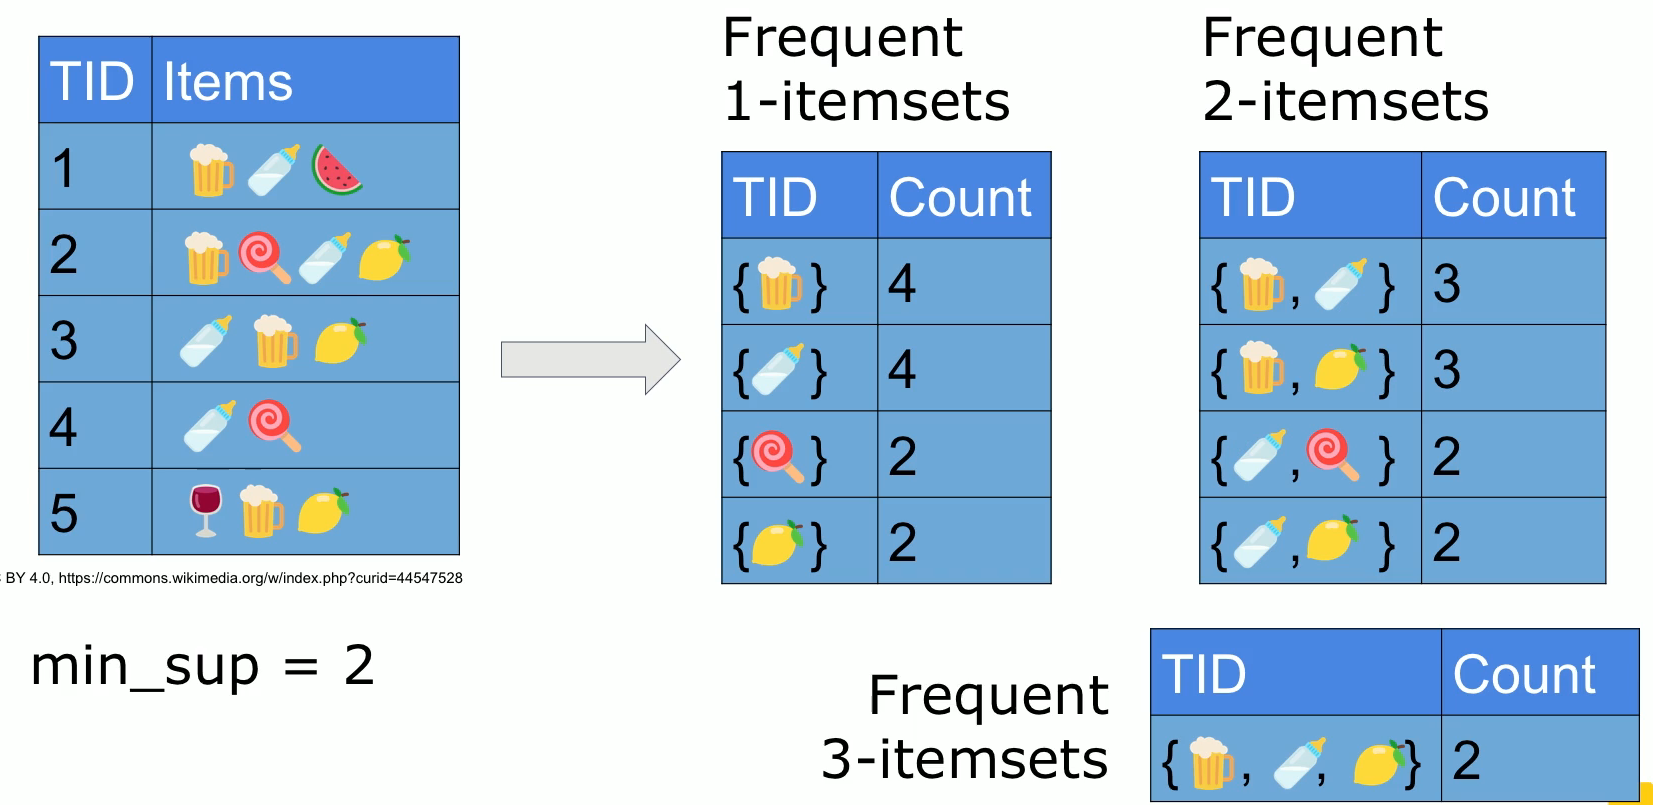

**Input**: Database D, minimal support min_sup

- $C_k$: candidate itemsets of size knowledge
- $L_k$: frequent itemsets of size k

### The Apriori Algorithm-Pseudo code 

```
L_1 = {frequent single items};
for (k = 1; != 0; k++) does
    $C_{k+1}$ = candidate of length K + 1 generated from L_k;
    for each transaction t in D do
        increment the count of each candidate in $C_{k+1}$ that appear in t 
        $L_{k+1} = candidates in $C_{k+1}$ with support >= min_sup 
    return {L_1, L_2, ..., L_{k-1}}

```


### Challenges of Apriori 

- Needs multiple scans of database
- Huge number of candidates (most are not frequent)
- Tedious workload of counting the frequency of every candidate 

### Further improvement of Apriori 

- Reduce passes of database scans 
- Shrink number of candidate
- Sampling and approximation
- Distributed counting (e.g., Map-Reduce)
- Refer to [Han, Kamber, Pei] Chapter 6, 7